# Gaussian Drift OPT Debug

Clean propagation check for the homogeneous 2D acoustic OPT operator. The baseline here is `YorderBspace = -1`, `YorderBtime = -1`, because that means the direct/indicator factor in `integralWYYKK` and avoids the ambiguous `YorderB = 0` case.


## 1. Setup


In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")

try
    using Metal
catch err
    @warn "Metal not loaded; continuing on CPU" err
end

ParamFile = "../config/testparam.csv"

include("../src/batchFiles/batchGPU.jl")
include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")
using .commonBatchs, .planet1D, .GeoPoints

include("../src/flexOPT.jl")
using .flexOPT

include("temporaryHelpers.jl")


  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


taylor_C_moment_report (generic function with 1 method)

## 2. Controls


In [2]:
shape = (201, 201)
center = CartesianIndex(cld(shape[1], 2), cld(shape[2], 2))

velocity_value = 2600.0
dx = 100.0
cfl = 0.45
dt = cfl * dx / velocity_value
delta = (dx, dx, dt)
velocity = fill(velocity_value, shape)

Nt = 180
store_every = 3
sigma = 10.0
amplitude = 1.0
init_gaussian = gaussian_field(shape, center; sigma=sigma, amplitude=amplitude)

pointsInSpace = 3
pointsInTime = 3
supplementaryOrder = 2
orderBspace = 1
orderBtime = 1
YorderBspace = -1
YorderBtime = -1

@show shape center velocity_value delta Nt store_every sigma
@show pointsInSpace pointsInTime supplementaryOrder orderBspace orderBtime YorderBspace YorderBtime


shape = (201, 201)
center = CartesianIndex(101, 101)
velocity_value = 2600.0
delta = (100.0, 100.0, 0.01730769230769231)
Nt = 180
store_every = 3
sigma = 10.0
pointsInSpace = 3
pointsInTime = 3
supplementaryOrder = 2
orderBspace = 1
orderBtime = 1
YorderBspace = -1
YorderBtime = -1


-1

## 3. Unit Stencil Sanity Check


In [3]:
toy_unit = build_toy_opt_prepared(
    famousEquationType="2DacousticHomoTime",
    velocity_value=1.0,
    shape=shape,
    dx=1.0,
    dt=1.0,
    pointsInSpace=pointsInSpace,
    pointsInTime=pointsInTime,
    supplementaryOrder=supplementaryOrder,
    orderBspace=orderBspace,
    orderBtime=orderBtime,
    YorderBspace=YorderBspace,
    YorderBtime=YorderBtime,
)

st_unit = operator_stencil_at_point(toy_unit.numOps, center; which=:left)
unit_matrices = stencil_matrices_by_time(st_unit)
unit_sums = sum.(getfield.(unit_matrices, :matrix))

stencil_time_summary(st_unit), unit_matrices, unit_sums, compare_stencil_scale_to_fd(st_unit, 1.0, 1.0, 1.0)


(vars, iVars) = (v, 1)
(vars, iVars) = (v, 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})
nTotalSmall

(NamedTuple[(time_slot = 1, time_role = :past_2, n = 9, sumcoef = 0.9999999999999981, sumabs = 1.0272222222222185, maxabs = 0.9863888888888872), (time_slot = 2, time_role = :present, n = 9, sumcoef = -1.9999999999999967, sumabs = 5.1211111111111105, maxabs = 1.560555555555557), (time_slot = 3, time_role = :future, n = 9, sumcoef = 0.9999999999999971, sumabs = 1.0272222222222214, maxabs = 0.9863888888888869)], NamedTuple[(time_slot = 1, time_role = :past_2, matrix = [-0.0034027777777777394 0.006805555555554635 -0.0034027777777785153; 0.006805555555555447 0.9863888888888872 0.006805555555555419; -0.003402777777776689 0.006805555555555419 -0.0034027777777771414]), (time_slot = 2, time_role = :present, matrix = [-0.10986111111111109 -0.7802777777777782 -0.10986111111111106; -0.7802777777777757 1.560555555555557 -0.7802777777777786; -0.10986111111111141 -0.7802777777777763 -0.10986111111111158]), (time_slot = 3, time_role = :future, matrix = [-0.003402777777778119 0.0068055555555557035 -0.0

## 4. FD Baseline Propagation


In [4]:
preparedFD = prepare_fd2d_acoustic_baseline(velocity, delta)
frames_fd = propagate_linear_frames_from_initial(
    preparedFD,
    init_gaussian,
    init_gaussian,
    Nt;
    store_every=store_every,
    blowup_limit=1e12,
)

fd_report = wavefield_snapshot_report(frames_fd)
fd_drift = drift_report(frames_fd, center)
fd_argmax = argmax_report(frames_fd, center)
fd_symmetry = symmetry_report(frames_fd, center)

@show length(frames_fd) fd_report[1] fd_report[end]
@show fd_drift[1] fd_drift[end]
@show fd_argmax[1] fd_argmax[end]
@show fd_symmetry[1] fd_symmetry[end]


length(frames_fd) = 61
fd_report[1] = (frame = 1, nbad = 0, finite_max = 1.0, minimum = 3.720075976020836e-44, maximum = 1.0)
fd_report[end] = (frame = 61, nbad = 0, finite_max = 0.12650212646124115, minimum = -0.07299382461789063, maximum = 0.12650212646124115)
fd_drift[1] = (frame = 1, cm_x = 100.99999999999979, cm_z = 101.00000000000017, drift_x = -2.1316282072803006e-13, drift_z = 1.7053025658242404e-13, maxabs = 1.0)
fd_drift[end] = (frame = 61, cm_x = 101.00000000000011, cm_z = 100.99999999999959, drift_x = 1.1368683772161603e-13, drift_z = -4.121147867408581e-13, maxabs = 0.12650212646124115)
fd_argmax[1] = (frame = 1, maxpoint = CartesianIndex(101, 101), dx = 0, dz = 0, value = 1.0, maxabs = 1.0)
fd_argmax[end] = (frame = 61, maxpoint = CartesianIndex(43, 165), dx = -58, dz = 64, value = 0.12650212646124115, maxabs = 0.12650212646124115)
fd_symmetry[1] = (frame = 1, lr = 0.0, ud = 0.0, diag = 0.0)
fd_symmetry[end] = (frame = 61, lr = 1.1842581322338107e-15, ud = 1.3256361873321

(frame = 61, lr = 1.1842581322338107e-15, ud = 1.325636187332138e-15, diag = 1.412088476802089e-15)

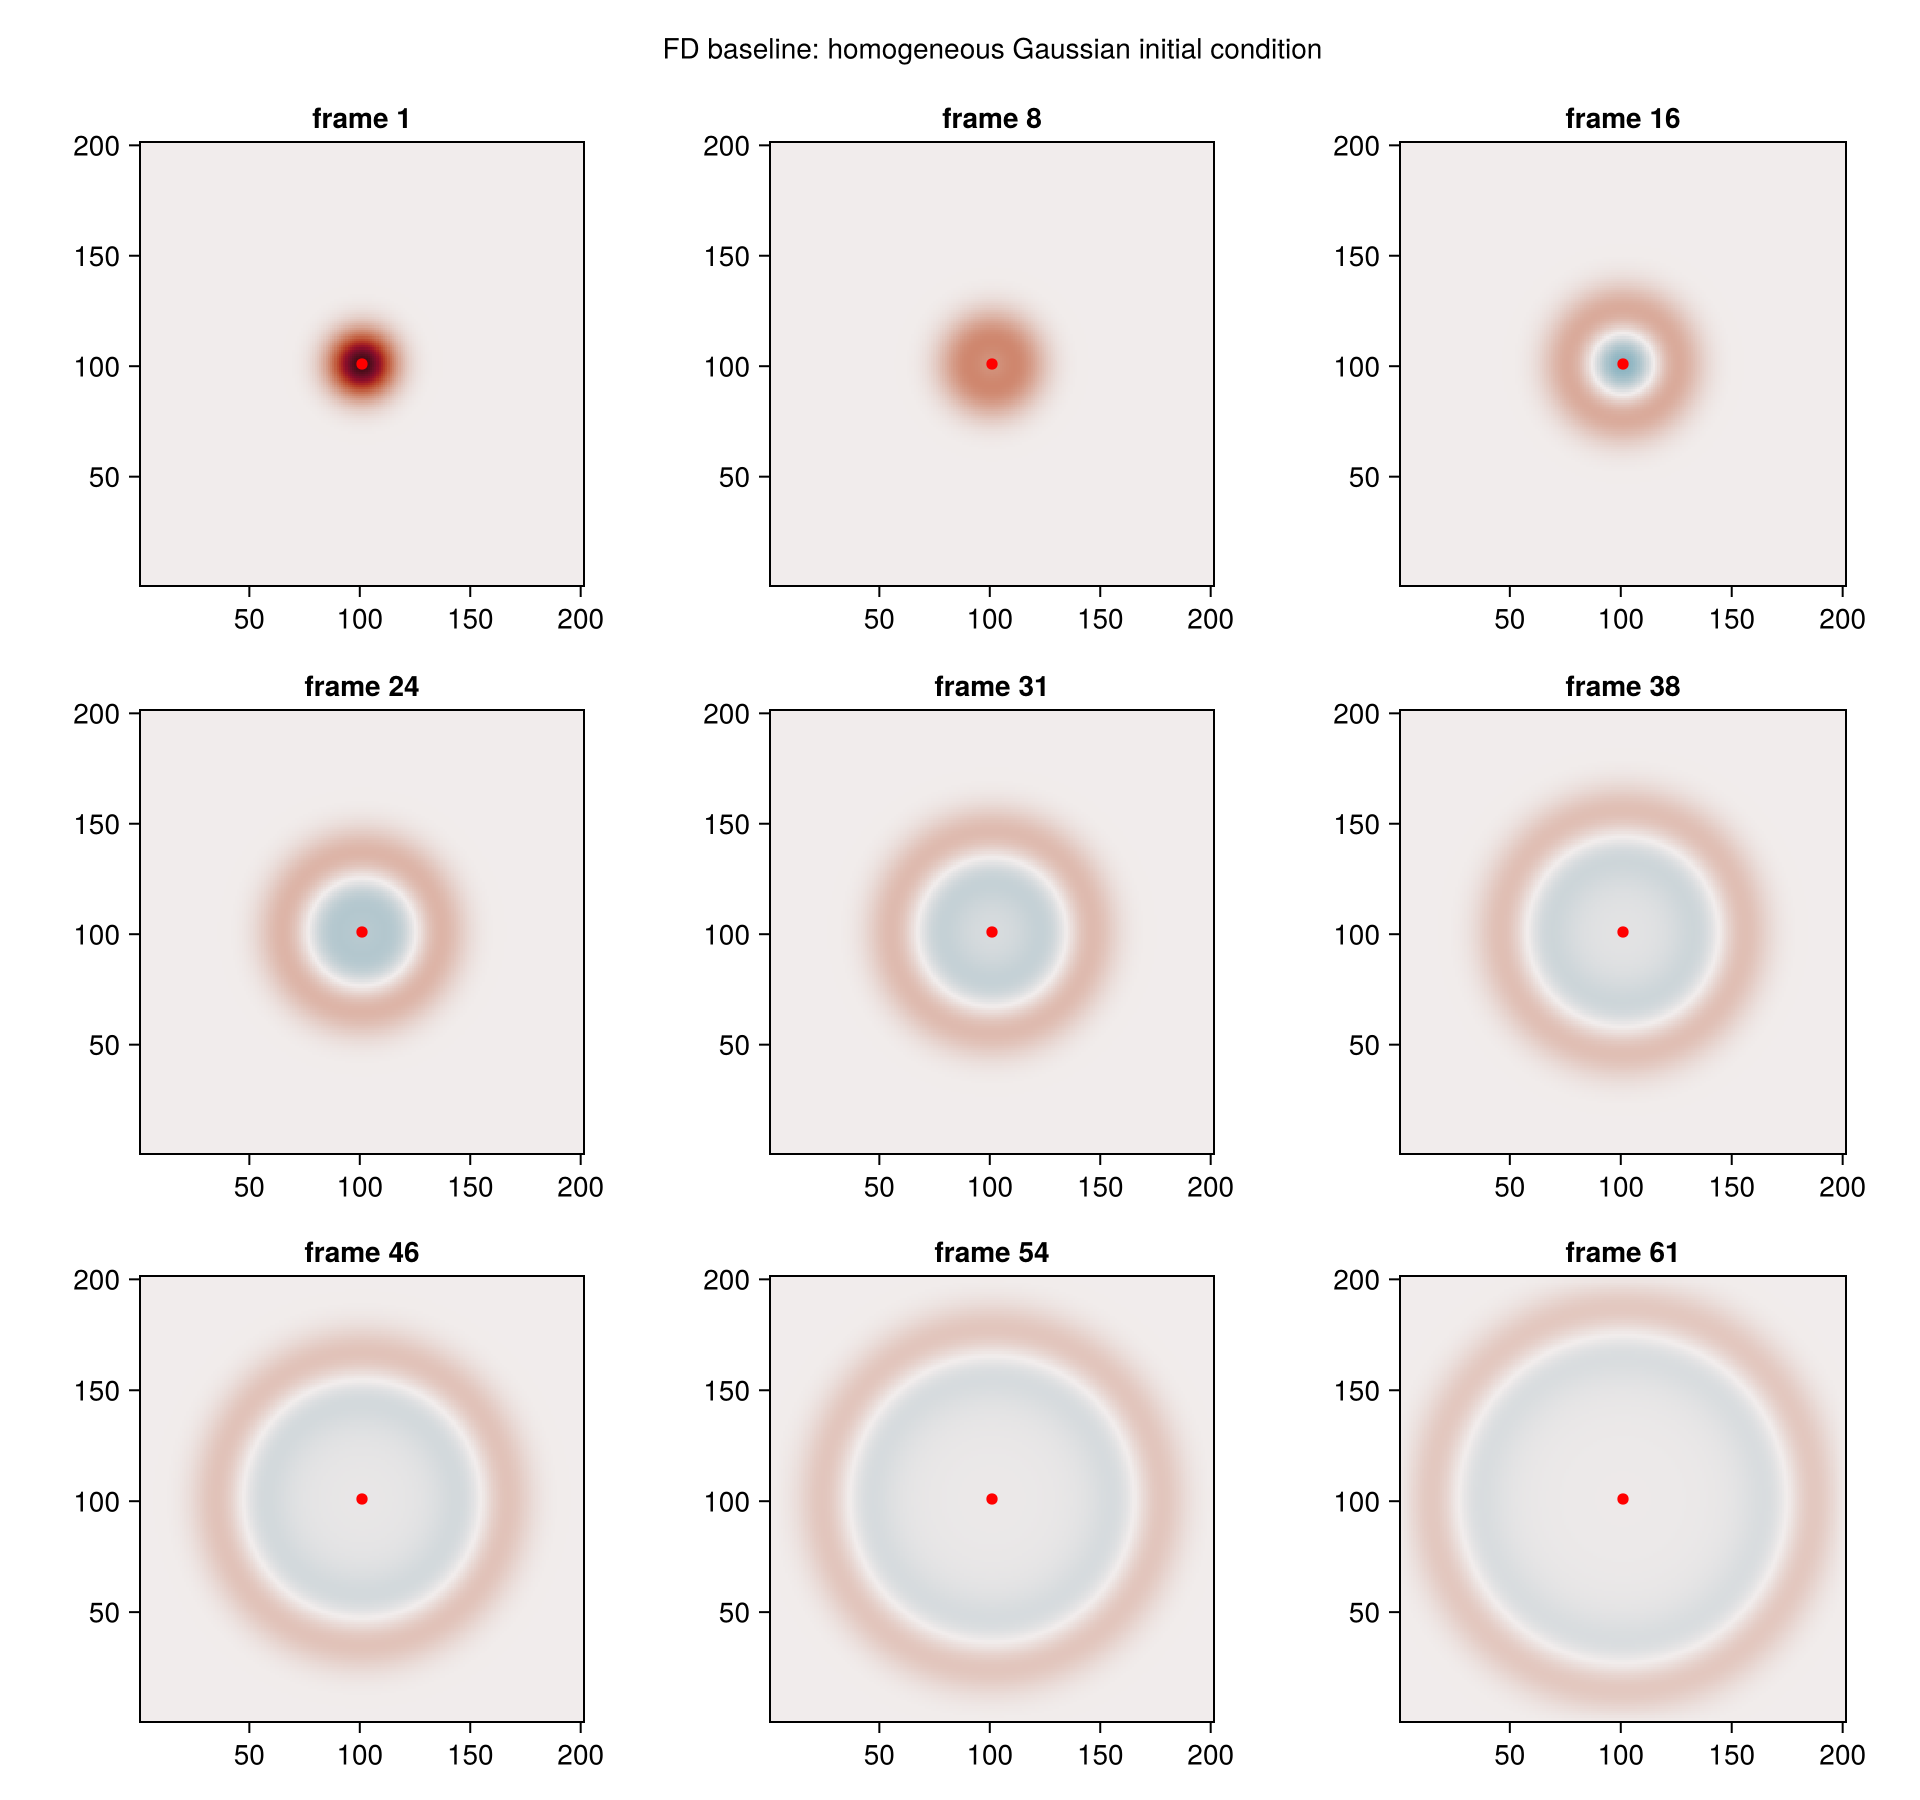

In [5]:
fig_fd = plot_wave_snapshots(
    frames_fd;
    sourcePoint=center,
    title="FD baseline: homogeneous Gaussian initial condition",
)
fig_fd


## 5. OPT Propagation With Y = -1


In [6]:
toyOPT = build_toy_opt_prepared(
    famousEquationType="2DacousticHomoTime",
    velocity_value=velocity_value,
    shape=shape,
    dx=dx,
    cfl=cfl,
    pointsInSpace=pointsInSpace,
    pointsInTime=pointsInTime,
    supplementaryOrder=supplementaryOrder,
    orderBspace=orderBspace,
    orderBtime=orderBtime,
    YorderBspace=YorderBspace,
    YorderBtime=YorderBtime,
)
preparedOPT = toyOPT.prepared

opt_A_report = implicit_matrix_report(preparedOPT)
st_opt = operator_stencil_at_point(toyOPT.numOps, center; which=:left)
opt_matrices = stencil_matrices_by_time(st_opt)
opt_sums = sum.(getfield.(opt_matrices, :matrix))

@show preparedOPT.spaceShape preparedOPT.NpointsSpace preparedOPT.timePointsUsedForOneStep
@show size(preparedOPT.A_unknown) nnz(preparedOPT.A_unknown) nnz(preparedOPT.L_known)
@show opt_A_report
stencil_time_summary(st_opt), opt_matrices, opt_sums


(vars, iVars) = (v, 1)
(vars, iVars) = (v, 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})
nTotalSmall

(NamedTuple[(time_slot = 1, time_role = :past_2, n = 9, sumcoef = 577777.7777529871, sumabs = 577777.7777529871, maxabs = 470262.9629351227), (time_slot = 2, time_role = :present, n = 9, sumcoef = -1.1555555555599583e6, sumabs = 1.1555555555599583e6, maxabs = 472525.92592539266), (time_slot = 3, time_role = :future, n = 9, sumcoef = 577777.7777831824, sumabs = 577777.7777831824, maxabs = 470262.9629692774)], NamedTuple[(time_slot = 1, time_role = :past_2, matrix = [3.0964266570500124e-9 26878.703708811052 3.096426713450133e-9; 26878.703702350045 470262.9629351227 26878.703705248605; 3.100763490289003e-9 26878.70370144224 3.096426672631406e-9]), (time_slot = 2, time_role = :present, matrix = [-1.9671253328063175e-8 -170757.407413911 -1.9671253350743654e-8; -170757.407406713 -472525.92592539266 -170757.40741018864; -1.967125333912913e-8 -170757.40740367456 -1.967125333374979e-8]), (time_slot = 3, time_role = :future, matrix = [3.0964266623348482e-9 26878.703705514497 3.0964266668059273e-

In [7]:
frames_opt = propagate_linear_frames_from_initial(
    preparedOPT,
    init_gaussian,
    init_gaussian,
    Nt;
    store_every=store_every,
    blowup_limit=1e12,
)

opt_report = wavefield_snapshot_report(frames_opt)
opt_drift = drift_report(frames_opt, center)
opt_argmax = argmax_report(frames_opt, center)
opt_symmetry = symmetry_report(frames_opt, center)

@show length(frames_opt) opt_report[1] opt_report[end]
@show opt_drift[1] opt_drift[end]
@show opt_argmax[1] opt_argmax[end]
@show opt_symmetry[1] opt_symmetry[end]


length(frames_opt) = 61
opt_report[1] = (frame = 1, nbad = 0, finite_max = 1.0, minimum = 3.720075976020836e-44, maximum = 1.0)
opt_report[end] = (frame = 61, nbad = 0, finite_max = 0.12666393594653216, minimum = -0.07264381226380476, maximum = 0.12666393594653216)
opt_drift[1] = (frame = 1, cm_x = 100.99999999999979, cm_z = 101.00000000000017, drift_x = -2.1316282072803006e-13, drift_z = 1.7053025658242404e-13, maxabs = 1.0)
opt_drift[end] = (frame = 61, cm_x = 100.9999999887249, cm_z = 101.00000005533609, drift_x = -1.1275105293861998e-8, drift_z = 5.5336087712021254e-8, maxabs = 0.12666393594653216)
opt_argmax[1] = (frame = 1, maxpoint = CartesianIndex(101, 101), dx = 0, dz = 0, value = 1.0, maxabs = 1.0)
opt_argmax[end] = (frame = 61, maxpoint = CartesianIndex(44, 166), dx = -57, dz = 65, value = 0.12666393594653216, maxabs = 0.12666393594653216)
opt_symmetry[1] = (frame = 1, lr = 0.0, ud = 0.0, diag = 0.0)
opt_symmetry[end] = (frame = 61, lr = 9.01585626550702e-11, ud = 4.03990721

(frame = 61, lr = 9.01585626550702e-11, ud = 4.0399072189239606e-10, diag = 4.17214588151682e-10)

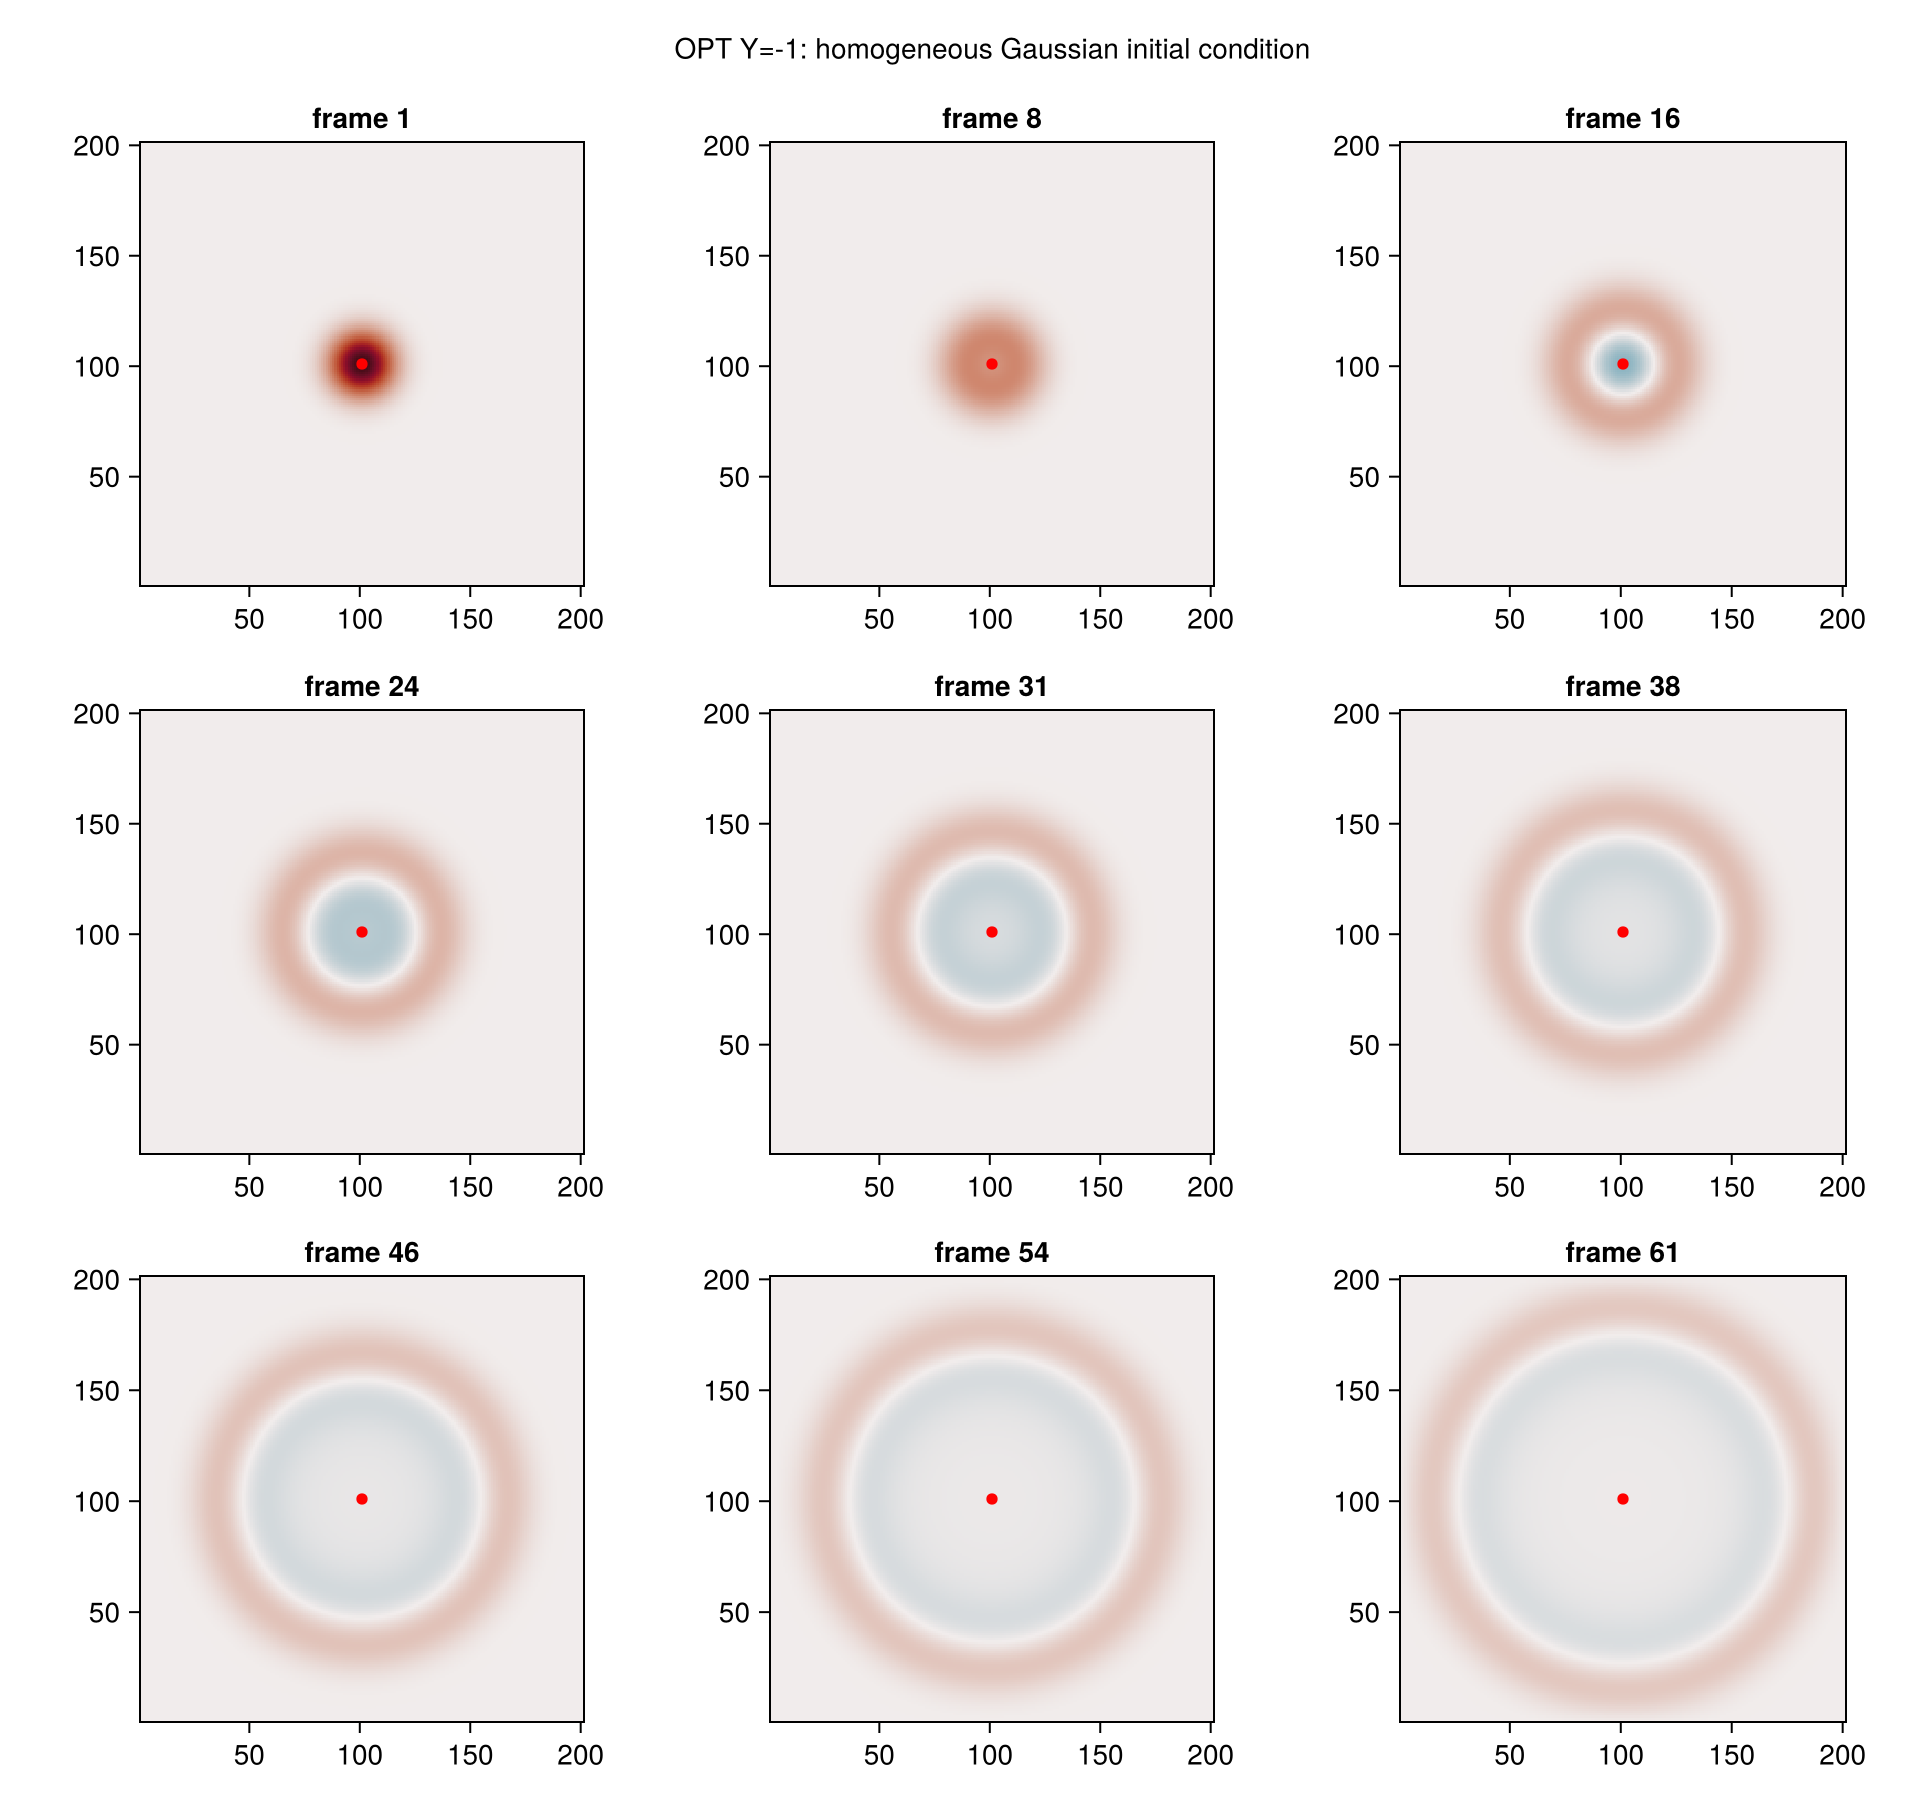

In [8]:
fig_opt = plot_wave_snapshots(
    frames_opt;
    sourcePoint=center,
    title="OPT Y=-1: homogeneous Gaussian initial condition",
)
fig_opt


## 6. Comparison


In [9]:
drift_comparison = (
    fd_final_drift = fd_drift[end],
    opt_final_drift = opt_drift[end],
    fd_final_argmax = fd_argmax[end],
    opt_final_argmax = opt_argmax[end],
    fd_final_symmetry = fd_symmetry[end],
    opt_final_symmetry = opt_symmetry[end],
    fd_final_max = maximum(abs, frames_fd[end]),
    opt_final_max = maximum(abs, frames_opt[end]),
)
drift_comparison


(fd_final_drift = (frame = 61, cm_x = 101.00000000000011, cm_z = 100.99999999999959, drift_x = 1.1368683772161603e-13, drift_z = -4.121147867408581e-13, maxabs = 0.12650212646124115), opt_final_drift = (frame = 61, cm_x = 100.9999999887249, cm_z = 101.00000005533609, drift_x = -1.1275105293861998e-8, drift_z = 5.5336087712021254e-8, maxabs = 0.12666393594653216), fd_final_argmax = (frame = 61, maxpoint = CartesianIndex(43, 165), dx = -58, dz = 64, value = 0.12650212646124115, maxabs = 0.12650212646124115), opt_final_argmax = (frame = 61, maxpoint = CartesianIndex(44, 166), dx = -57, dz = 65, value = 0.12666393594653216, maxabs = 0.12666393594653216), fd_final_symmetry = (frame = 61, lr = 1.1842581322338107e-15, ud = 1.325636187332138e-15, diag = 1.412088476802089e-15), opt_final_symmetry = (frame = 61, lr = 9.01585626550702e-11, ud = 4.0399072189239606e-10, diag = 4.17214588151682e-10), fd_final_max = 0.12650212646124115, opt_final_max = 0.12666393594653216)

## 7. Optional Parameter Sweep


In [10]:
parameter_cases = [
    (pointsInSpace=3, supplementaryOrder=2, YorderBspace=-1, YorderBtime=-1),
    (pointsInSpace=5, supplementaryOrder=2, YorderBspace=-1, YorderBtime=-1),
]

sweep_rows = NamedTuple[]
for case in parameter_cases
    println("building OPT case ", case)
    a_report = nothing
    try
        toy = build_toy_opt_prepared(
            famousEquationType="2DacousticHomoTime",
            velocity_value=velocity_value,
            shape=shape,
            dx=dx,
            cfl=cfl,
            pointsInSpace=case.pointsInSpace,
            pointsInTime=pointsInTime,
            supplementaryOrder=case.supplementaryOrder,
            orderBspace=orderBspace,
            orderBtime=orderBtime,
            YorderBspace=case.YorderBspace,
            YorderBtime=case.YorderBtime,
        )
        a_report = implicit_matrix_report(toy.prepared)
        if a_report.stored_nonfinite > 0 || a_report.zero_rows_finite > 0
            push!(sweep_rows, (; case..., status=:bad_A_unknown, matrix_report=a_report, nframes=0, final_drift=nothing, final_symmetry=nothing, final_max=NaN))
            @warn "Skipping OPT case because A_unknown is non-finite or has finite-zero rows" case matrix_report=a_report
            continue
        end
        fr = propagate_linear_frames_from_initial(toy.prepared, init_gaussian, init_gaussian, Nt; store_every=store_every, blowup_limit=1e12)
        dr = drift_report(fr, center)
        sy = symmetry_report(fr, center)
        push!(sweep_rows, (; case..., status=:ok, matrix_report=a_report, nframes=length(fr), final_drift=dr[end], final_symmetry=sy[end], final_max=maximum(abs, fr[end])))
    catch err
        push!(sweep_rows, (; case..., status=Symbol(nameof(typeof(err))), matrix_report=a_report, nframes=0, final_drift=nothing, final_symmetry=nothing, final_max=NaN))
        @warn "Skipping failed OPT case" case matrix_report=a_report exception=(err, catch_backtrace())
    end
end
sweep_rows


building OPT case (pointsInSpace = 3, supplementaryOrder = 2, YorderBspace = -1, YorderBtime = -1)
(vars, iVars) = (v, 1)
(vars, iVars) = (v, 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]
(typeof(μPoints), μPoints[1], typeof(pointsIn

┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/WYYKKIntegralSymbolic/WYYKKIntegralSymbolic_51ca1f72.jld2 does not exist. Producing it now...
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:106
┌ Warning: The Git repository ('/Users/nobuaki/Documents/Github/flexOPT') is dirty! Appending -dirty to the commit ID.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_tools.jl:71


(typeof(μPoints), μPoints[1], typeof(pointsIndices)) = (Array{SVector{3, Float64}, 3}, [2.0, 2.0, 2.0], Array{SVector{3, Int64}, 3})
nTotalSmallα = sum((length(bigα[iExpr, iField]) for iField = 1:NtypeofFields, iExpr = 1:NtypeofExpr)) = 3
all_sizes = collect.(size.(coefWYYKK)) = [[7, 7, 1, 1, 1], [7, 7, 1, 1, 1], [5, 5, 1, 1, 1]]

┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/WYYKKIntegralSymbolic/WYYKKIntegralSymbolic_51ca1f72.jld2 saved.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:115



typeof(output_gpu) = Array{Float64, 4}
"GPU computation of Ajiννᶜ: done" = "GPU computation of Ajiννᶜ: done"
nodeValue = eachα.node = -(v^2)
nodeValue = eachα.node = -(v^2)
nodeValue = eachα.node = 1
(vars, iVars) = (f(x, y, t), 1)
(vars, iVars) = (f(x, y, t), 1)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1] [1, 4, 1] [1, 5, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1] [2, 4, 1] [2, 5, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1] [3, 4, 1] [3, 5, 1]; [4, 1, 1] [4, 2, 1] [4, 3, 1] [4, 4, 1] [4, 5, 1]; [5, 1, 1] [5, 2, 1] [5, 3, 1] [5, 4, 1] [5, 5, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2] [1, 4, 2] [1, 5, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2] [2, 4, 2] [2, 5, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2] [3, 4, 2] [3, 5, 2]; [4, 1, 2] [4, 2, 2] [4, 3, 2] [4, 4, 2] [4, 5, 2]; [5, 1, 2] [5, 2, 2] [5, 3, 2] [5, 4, 2] [5, 5, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3] [1, 4, 3] [1, 5, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3] [2, 4, 3] [2, 5, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3] [3, 4,

┌ Error: A_unknown factorization failed
│   exception = (SingularException(0), Union{Ptr{Nothing}, Base.InterpreterIP}[Ptr{Nothing}(0x000000034f6aeacb), Ptr{Nothing}(0x000000034f6a4297), Ptr{Nothing}(0x000000034f6a47e3), Ptr{Nothing}(0x000000034f7dd06f), Ptr{Nothing}(0x000000010718302b), Ptr{Nothing}(0x0000000107182e0f), Ptr{Nothing}(0x000000010718406b), Ptr{Nothing}(0x000000011b4a686b), Ptr{Nothing}(0x0000000112ea4247), Ptr{Nothing}(0x0000000107154c73), Ptr{Nothing}(0x0000000112e54513), Ptr{Nothing}(0x0000000112e8431f), Ptr{Nothing}(0x0000000112e9410f), Ptr{Nothing}(0x0000000112e941d3), Ptr{Nothing}(0x000000012dc6c837), Ptr{Nothing}(0x000000012dc6cbdf), Ptr{Nothing}(0x0000000112bbd2b3), Ptr{Nothing}(0x0000000112bd405f), Ptr{Nothing}(0x0000000112bd4123), Ptr{Nothing}(0x0000000112a1cd77), Ptr{Nothing}(0x000000010718302b), Ptr{Nothing}(0x0000000107182e0f), Ptr{Nothing}(0x000000010718406b), Ptr{Nothing}(0x000000011b4a686b), Ptr{Nothing}(0x000000011c755f0f), Ptr{Nothing}(0x000000011c11290f

2-element Vector{NamedTuple}:
 (pointsInSpace = 3, supplementaryOrder = 2, YorderBspace = -1, YorderBtime = -1, status = :ok, matrix_report = (size = (40401, 40401), nnz = 361201, stored_finite = 361201, stored_nonfinite = 0, stored_nan = 0, stored_inf = 0, zero_rows_finite = 0, rows_with_nonfinite = 0, finite_abs_min = 3.0964266623348482e-9, finite_abs_median = 26878.703701804883, finite_abs_max = 470262.9629692774, diag_finite_count = 40401, diag_nonfinite_count = 0, diag_abs_min = 470262.9629692774, diag_abs_median = 470262.9629692774, diag_abs_max = 470262.9629692774, finite_row_abs_min = 524020.3703733327, finite_row_abs_max = 577777.7777831824), nframes = 61, final_drift = (frame = 61, cm_x = 100.9999999887249, cm_z = 101.00000005533609, drift_x = -1.1275105293861998e-8, drift_z = 5.5336087712021254e-8, maxabs = 0.12666393594653216), final_symmetry = (frame = 61, lr = 9.01585626550702e-11, ud = 4.0399072189239606e-10, diag = 4.17214588151682e-10), final_max = 0.12666393594653216)